# EDA — Campo Trebolares
**Clima histórico · Balance hídrico · Aptitud agronómica**

Requiere haber corrido los 3 scripts de extracción:
```bash
python scripts/01_fetch_climate.py
python scripts/02_fetch_soil_terrain.py
python scripts/03_compute_agro.py
```

In [1]:
import sys
from pathlib import Path

# Asegura que podemos importar src/ desde notebooks/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
NAVY   = '#1E3953'
ORANGE = '#EF9645'
BLUE   = '#607E93'

PROC = ROOT / 'data' / 'trebolares' / 'processed'
RAW  = ROOT / 'data' / 'trebolares' / 'raw'
print('ROOT:', ROOT)

ROOT: C:\Users\Usuario\OneDrive\appsheet\Antigravity\Proyecto ClimaData


## 1 · Carga de datos

In [2]:
daily   = pd.read_parquet(RAW  / 'climate_daily.parquet')
annual  = pd.read_parquet(PROC / 'climate_annual.parquet')
monthly_by_year = pd.read_parquet(PROC / 'climate_monthly_by_year.parquet')
monthly_clim    = pd.read_parquet(PROC / 'climate_monthly_climatology.parquet')

with open(PROC / 'climate_indicators.json') as f:
    indicators = json.load(f)
with open(PROC / 'soil.json') as f:
    soil = json.load(f)
with open(PROC / 'terrain.json') as f:
    terrain = json.load(f)

print(f"Clima diario: {len(daily):,} filas  ({daily['date'].min().date()} → {daily['date'].max().date()})")
print(f"Años completos: {len(annual)}")
print(f"Suelo disponible: {soil.get('available')}  |  Terreno disponible: {terrain.get('available')}")

Clima diario: 9,131 filas  (2001-01-01 → 2025-12-31)
Años completos: 25
Suelo disponible: 0.0  |  Terreno disponible: 1.0


In [3]:
# Cargar campañas agronómicas
SCENARIO_KEYS = ['maize_early', 'maize_late', 'wheat', 'soy_first', 'soy_second']
SCENARIO_LABELS = {
    'maize_early': 'Maíz temprano',
    'maize_late':  'Maíz tardío',
    'wheat':       'Trigo',
    'soy_first':   'Soja 1ª',
    'soy_second':  'Soja 2ª',
}

campaigns = {}
for key in SCENARIO_KEYS:
    path = PROC / f'agro_{key}_campaign_summary.parquet'
    if path.exists():
        df = pd.read_parquet(path)
        df['scenario'] = SCENARIO_LABELS[key]
        campaigns[key] = df
    else:
        print(f'  ⚠ falta {path.name}')

print(f'Escenarios cargados: {list(campaigns.keys())}')

Escenarios cargados: ['maize_early', 'maize_late', 'wheat', 'soy_first', 'soy_second']


---
## 2 · Precipitación anual

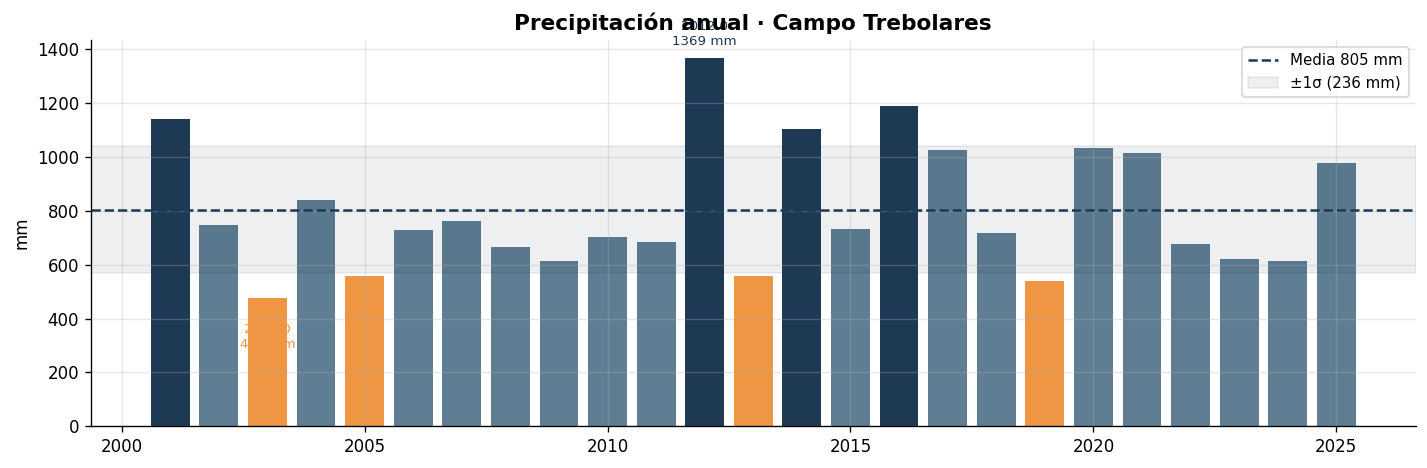

Media: 805 mm  |  σ: 236 mm  |  CV: 29.3%
Más seco: 2003 (478 mm)  |  Más húmedo: 2012 (1369 mm)


In [4]:
mean_p = annual['precipitation_mm'].mean()
std_p  = annual['precipitation_mm'].std()

fig, ax = plt.subplots(figsize=(12, 4))
colors = [ORANGE if v < mean_p - std_p else NAVY if v > mean_p + std_p else BLUE
          for v in annual['precipitation_mm']]
ax.bar(annual['year'], annual['precipitation_mm'], color=colors, width=0.8)
ax.axhline(mean_p, color=NAVY, lw=1.5, ls='--', label=f'Media {mean_p:.0f} mm')
ax.axhspan(mean_p - std_p, mean_p + std_p, alpha=0.08, color=NAVY, label=f'±1σ ({std_p:.0f} mm)')

# Anotar año más seco y más húmedo
dry_y = annual.loc[annual['precipitation_mm'].idxmin()]
wet_y = annual.loc[annual['precipitation_mm'].idxmax()]
ax.annotate(f"{dry_y['year']}\n{dry_y['precipitation_mm']:.0f} mm",
            (dry_y['year'], dry_y['precipitation_mm']), textcoords='offset points',
            xytext=(0, -30), ha='center', fontsize=8, color=ORANGE)
ax.annotate(f"{wet_y['year']}\n{wet_y['precipitation_mm']:.0f} mm",
            (wet_y['year'], wet_y['precipitation_mm']), textcoords='offset points',
            xytext=(0, 8), ha='center', fontsize=8, color=NAVY)

ax.set_title('Precipitación anual · Campo Trebolares', fontsize=13, fontweight='bold')
ax.set_ylabel('mm')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

cv = std_p / mean_p * 100
print(f'Media: {mean_p:.0f} mm  |  σ: {std_p:.0f} mm  |  CV: {cv:.1f}%')
print(f'Más seco: {int(dry_y["year"])} ({dry_y["precipitation_mm"]:.0f} mm)  |  '
      f'Más húmedo: {int(wet_y["year"])} ({wet_y["precipitation_mm"]:.0f} mm)')

---
## 3 · Temperatura anual

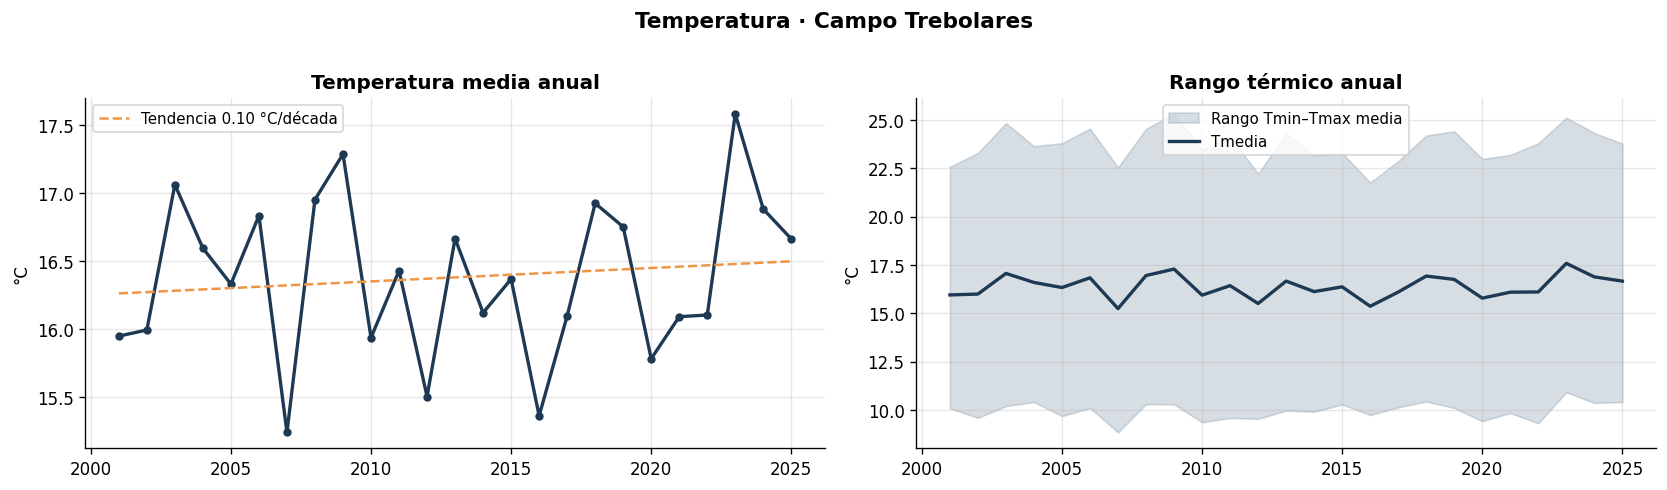

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Temperatura media
ax = axes[0]
ax.plot(annual['year'], annual['temp_mean_c'], color=NAVY, lw=2, marker='o', ms=4)
z = np.polyfit(annual['year'], annual['temp_mean_c'], 1)
ax.plot(annual['year'], np.polyval(z, annual['year']), color=ORANGE, lw=1.5, ls='--',
        label=f'Tendencia {z[0]*10:.2f} °C/década')
ax.set_title('Temperatura media anual', fontweight='bold')
ax.set_ylabel('°C')
ax.legend(fontsize=9)

# Rango térmico anual
ax = axes[1]
ax.fill_between(annual['year'], annual['temp_min_c'], annual['temp_max_c'],
                alpha=0.25, color=BLUE, label='Rango Tmin–Tmax media')
ax.plot(annual['year'], annual['temp_mean_c'], color=NAVY, lw=2, label='Tmedia')
ax.set_title('Rango térmico anual', fontweight='bold')
ax.set_ylabel('°C')
ax.legend(fontsize=9)

plt.suptitle('Temperatura · Campo Trebolares', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4 · Climatología mensual

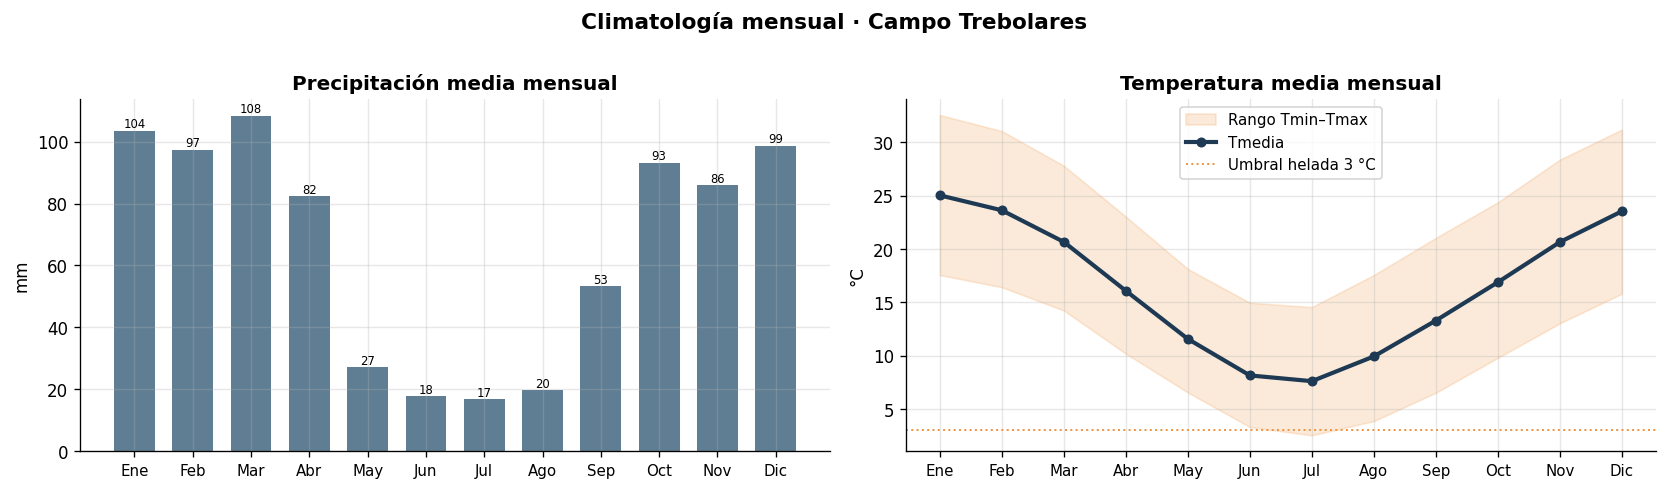

Meses con Tmin media ≤ 3 °C (riesgo de helada): ['Jul']


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Precipitación mensual media
ax = axes[0]
ax.bar(monthly_clim['month'], monthly_clim['precipitation_mm'], color=BLUE, width=0.7)
ax.set_xticks(monthly_clim['month'])
ax.set_xticklabels(monthly_clim['month_label'], fontsize=9)
ax.set_ylabel('mm')
ax.set_title('Precipitación media mensual', fontweight='bold')
for _, row in monthly_clim.iterrows():
    ax.text(row['month'], row['precipitation_mm'] + 1, f"{row['precipitation_mm']:.0f}",
            ha='center', fontsize=7)

# Temperatura mensual media con rango
ax = axes[1]
ax.fill_between(monthly_clim['month'], monthly_clim['temp_min_c'], monthly_clim['temp_max_c'],
                alpha=0.2, color=ORANGE, label='Rango Tmin–Tmax')
ax.plot(monthly_clim['month'], monthly_clim['temp_mean_c'], color=NAVY, lw=2.5,
        marker='o', ms=5, label='Tmedia')
ax.axhline(3, color=ORANGE, ls=':', lw=1.2, label='Umbral helada 3 °C')
ax.set_xticks(monthly_clim['month'])
ax.set_xticklabels(monthly_clim['month_label'], fontsize=9)
ax.set_ylabel('°C')
ax.set_title('Temperatura media mensual', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Climatología mensual · Campo Trebolares', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

frost_months = monthly_clim.loc[monthly_clim['temp_min_c'] <= 3, 'month_label'].tolist()
print(f'Meses con Tmin media ≤ 3 °C (riesgo de helada): {frost_months or "ninguno"}')

---
## 5 · Variabilidad interanual — distribución mensual

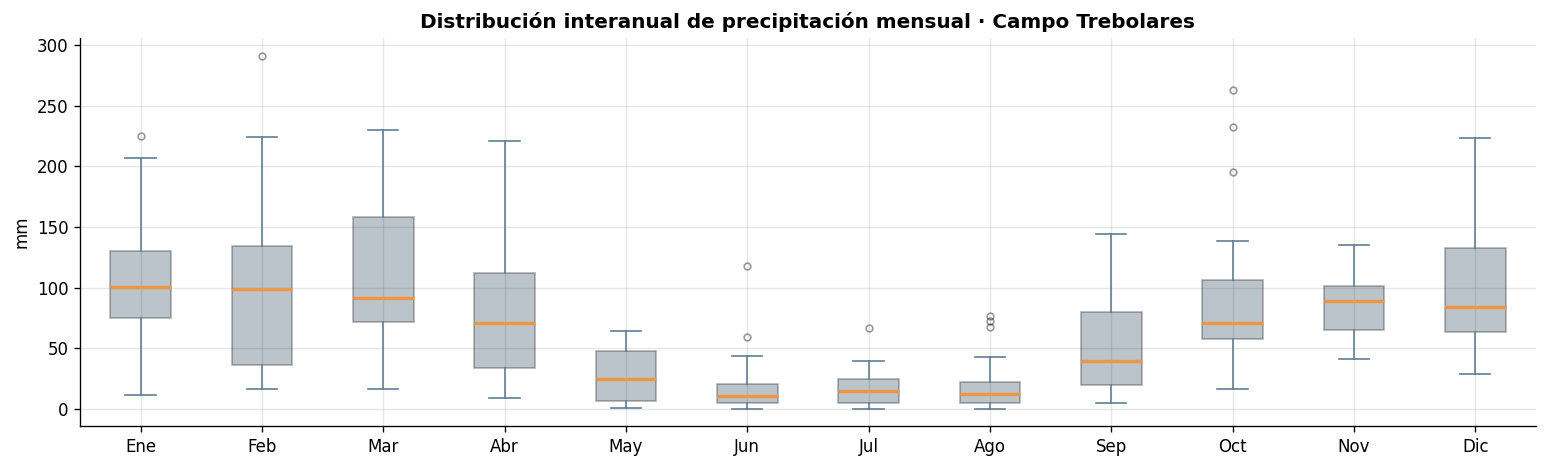

In [7]:
MONTH_LABELS = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(13, 4))
data_by_month = [
    monthly_by_year.loc[monthly_by_year['month'] == m, 'precipitation_mm'].values
    for m in range(1, 13)
]
bp = ax.boxplot(data_by_month, patch_artist=True, medianprops=dict(color=ORANGE, lw=2),
                whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.4, ms=4))
for patch in bp['boxes']:
    patch.set_facecolor(NAVY)
    patch.set_alpha(0.3)
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('mm')
ax.set_title('Distribución interanual de precipitación mensual · Campo Trebolares',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Días cálidos y fríos por año

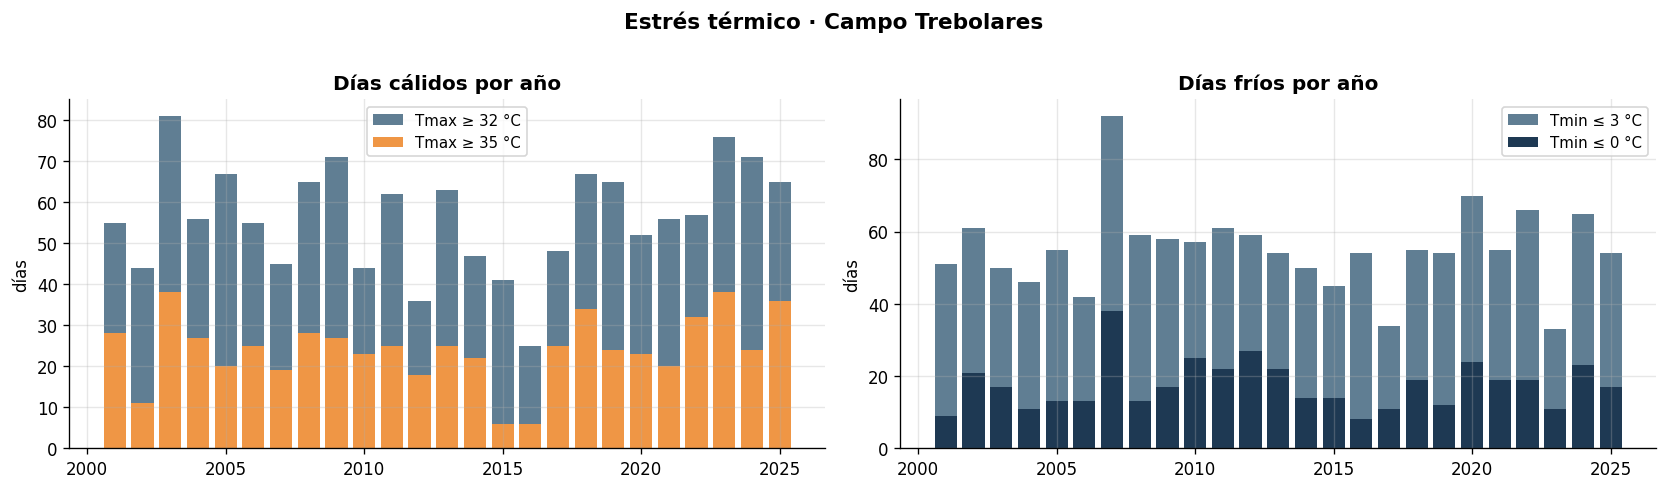

 year  hot_35  hot_32  cold_0  cold_3
 2001      28      55       9      51
 2002      11      44      21      61
 2003      38      81      17      50
 2004      27      56      11      46
 2005      20      67      13      55
 2006      25      55      13      42
 2007      19      45      38      92
 2008      28      65      13      59
 2009      27      71      17      58
 2010      23      44      25      57
 2011      25      62      22      61
 2012      18      36      27      59
 2013      25      63      22      54
 2014      22      47      14      50
 2015       6      41      14      45
 2016       6      25       8      54
 2017      25      48      11      34
 2018      34      67      19      55
 2019      24      65      12      54
 2020      23      52      24      70
 2021      20      56      19      55
 2022      32      57      19      66
 2023      38      76      11      33
 2024      24      71      23      65
 2025      36      65      17      54


In [8]:
daily['year'] = pd.to_datetime(daily['date']).dt.year

thermal = daily.groupby('year').agg(
    hot_35 =('temp_max_c', lambda s: (s >= 35).sum()),
    hot_32 =('temp_max_c', lambda s: (s >= 32).sum()),
    cold_0 =('temp_min_c', lambda s: (s <= 0).sum()),
    cold_3 =('temp_min_c', lambda s: (s <= 3).sum()),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(thermal['year'], thermal['hot_32'], color=BLUE, width=0.8, label='Tmax ≥ 32 °C')
ax.bar(thermal['year'], thermal['hot_35'], color=ORANGE, width=0.8, label='Tmax ≥ 35 °C')
ax.set_title('Días cálidos por año', fontweight='bold')
ax.set_ylabel('días')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(thermal['year'], thermal['cold_3'], color=BLUE, width=0.8, label='Tmin ≤ 3 °C')
ax.bar(thermal['year'], thermal['cold_0'], color=NAVY, width=0.8, label='Tmin ≤ 0 °C')
ax.set_title('Días fríos por año', fontweight='bold')
ax.set_ylabel('días')
ax.legend(fontsize=9)

plt.suptitle('Estrés térmico · Campo Trebolares', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(thermal.to_string(index=False))

---
## 7 · Scores agronómicos por escenario

In [9]:
# Resumen global por escenario
rows = []
for key in SCENARIO_KEYS:
    meta_path = PROC / f'agro_{key}_meta.json'
    if not meta_path.exists():
        continue
    with open(meta_path) as f:
        meta = json.load(f)
    gs = meta['global_summary']
    rows.append({
        'Escenario':  SCENARIO_LABELS[key],
        'Score medio': gs['mean_score'],
        'Favorable %': gs['favorable_pct'],
        'Intermedia %': gs['intermediate_pct'],
        'Restrictiva %': gs['restrictive_pct'],
        'Balance crítico (mm)': gs['mean_critical_balance_mm'],
        'Banda': gs['score_band'],
        'Mejor campaña': gs['best_campaign'],
        'Peor campaña': gs['worst_campaign'],
    })

summary_df = pd.DataFrame(rows).set_index('Escenario')
summary_df

,Score medio,Favorable %,Intermedia %,Restrictiva %,Balance crítico (mm),Banda,Mejor campaña,Peor campaña
Escenario,,,,,,,,
Maíz temprano,34.0,0.0,20.8,79.2,-328.9,Restrictivo,2015/16,2017/18
Maíz tardío,44.5,29.2,16.7,54.2,-126.5,Restrictivo,2016/17,2022/23
Trigo,40.4,12.0,12.0,76.0,-178.9,Restrictivo,2016/16,2019/19
Soja 1ª,44.5,16.7,20.8,62.5,-197.7,Restrictivo,2015/16,2017/18
Soja 2ª,49.6,33.3,16.7,50.0,-126.2,Intermedio,2011/12,2017/18


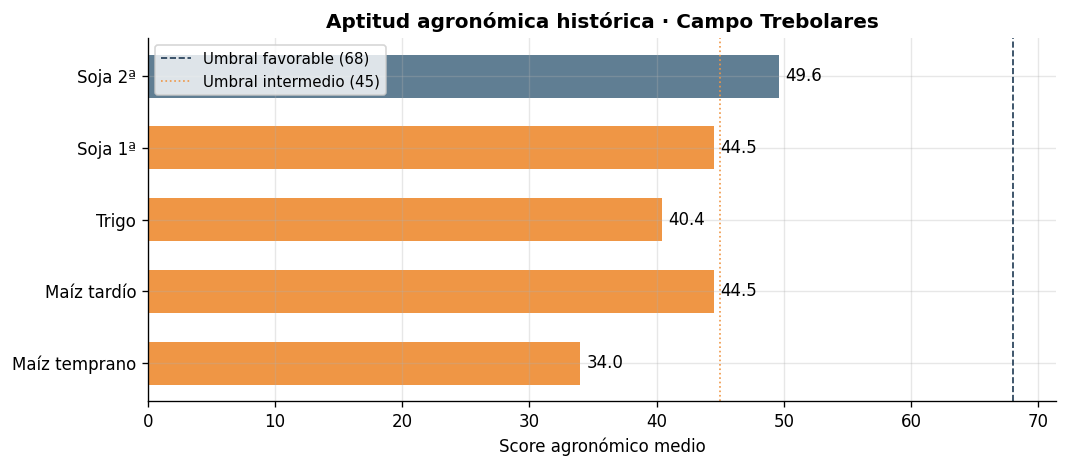

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
y_pos = range(len(summary_df))
colors_bar = [
    NAVY if v >= 68 else BLUE if v >= 45 else ORANGE
    for v in summary_df['Score medio']
]
bars = ax.barh(list(summary_df.index), summary_df['Score medio'], color=colors_bar, height=0.6)
ax.axvline(68, color=NAVY, ls='--', lw=1, label='Umbral favorable (68)')
ax.axvline(45, color=ORANGE, ls=':', lw=1, label='Umbral intermedio (45)')
for bar, val in zip(bars, summary_df['Score medio']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f'{val:.1f}',
            va='center', fontsize=10)
ax.set_xlabel('Score agronómico medio')
ax.set_title('Aptitud agronómica histórica · Campo Trebolares', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8 · Evolución del score por campaña

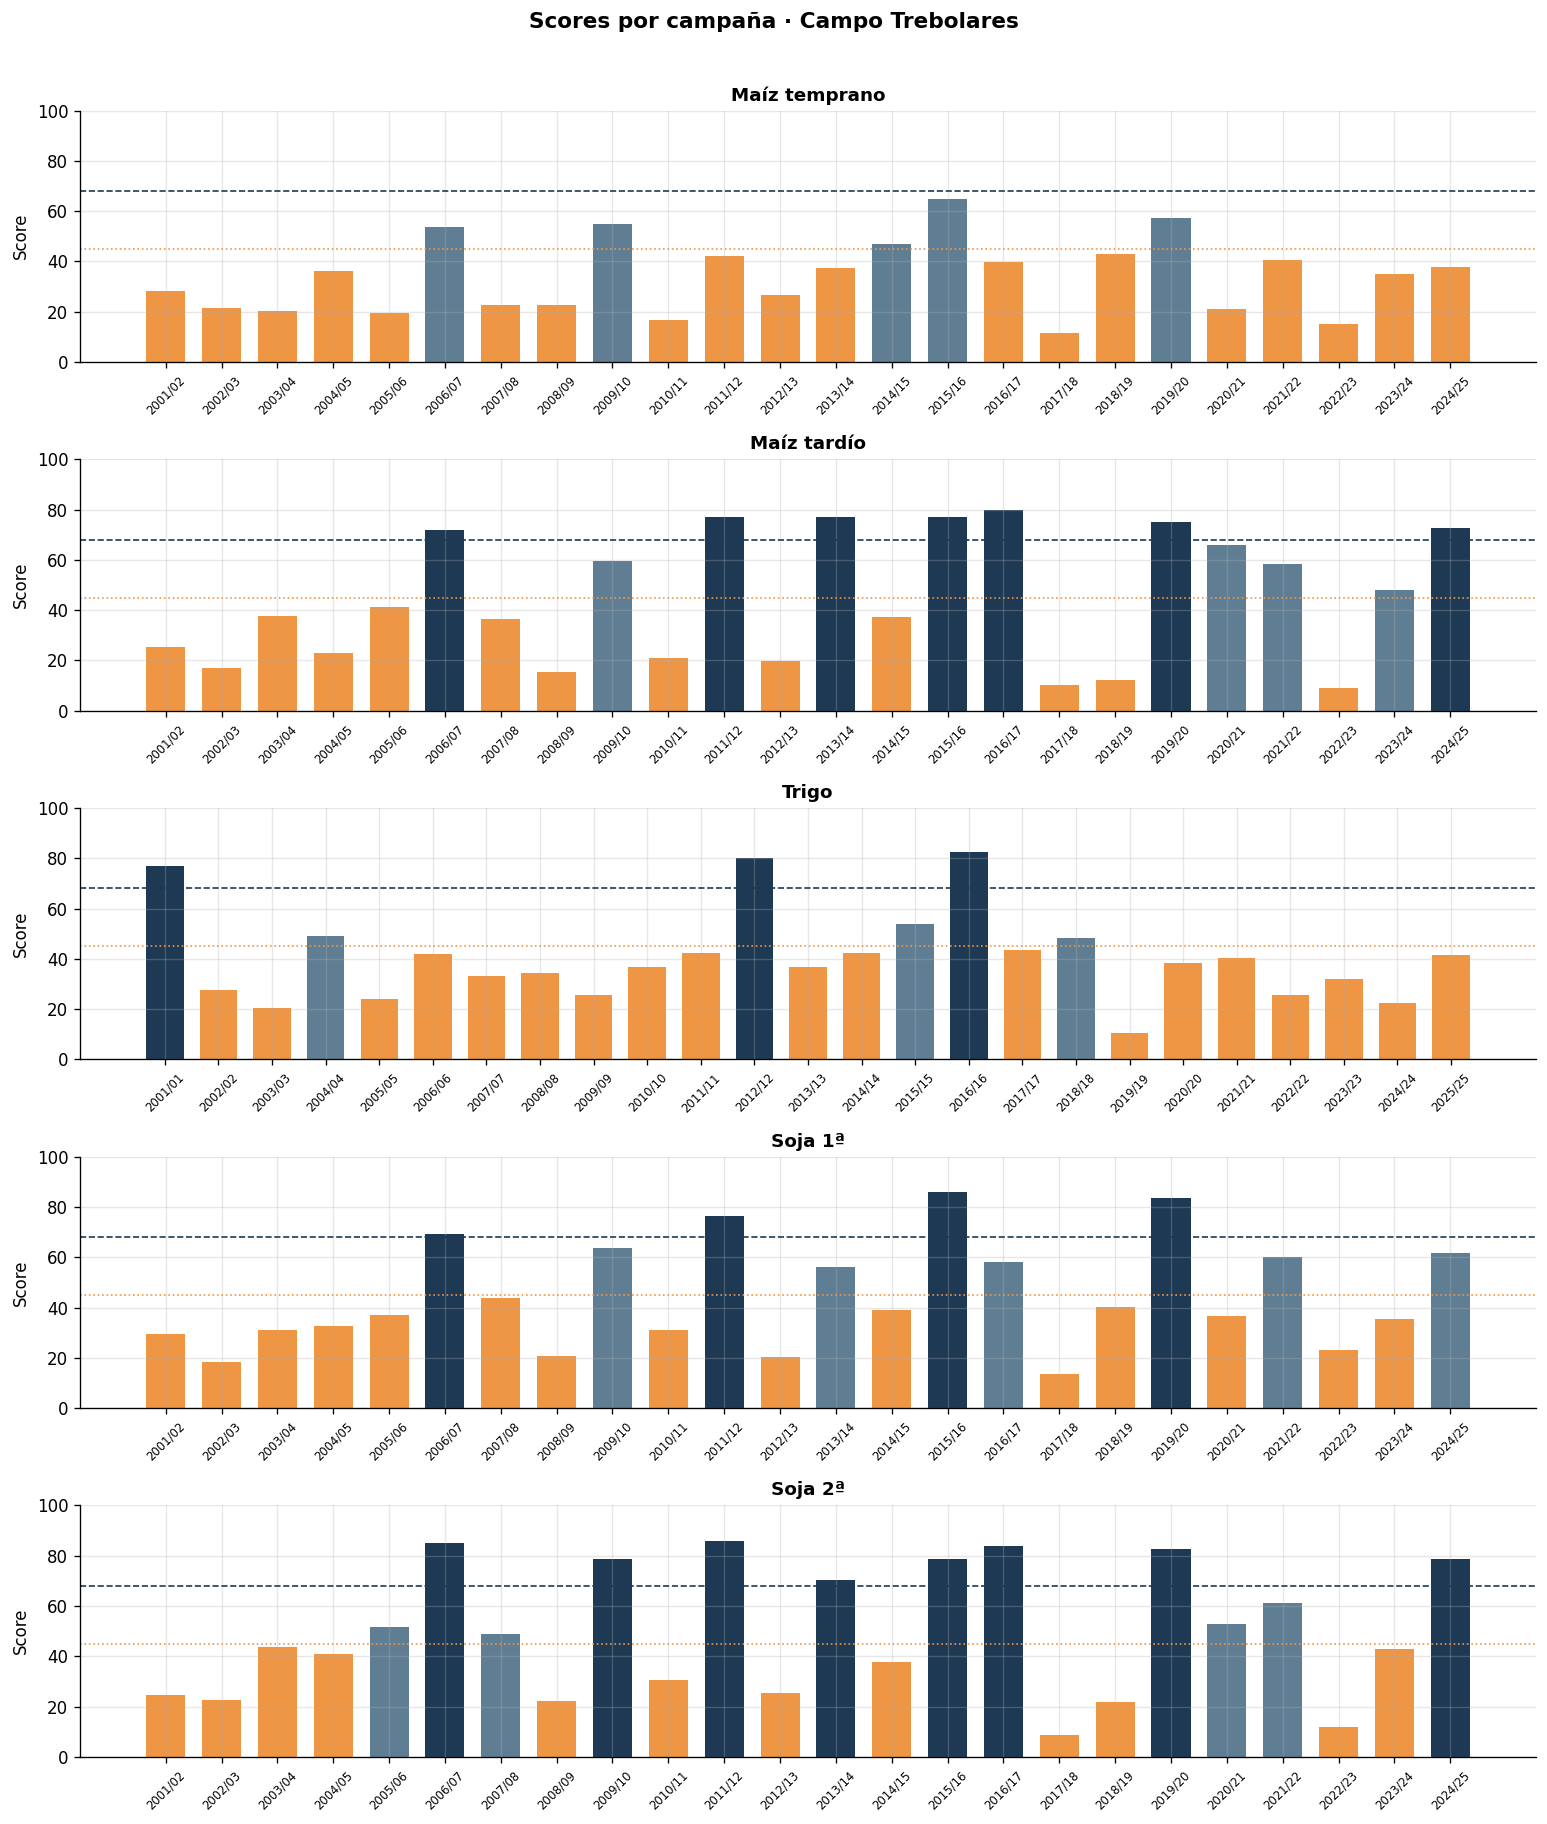

In [11]:
CLASS_COLOR = {'Favorable': NAVY, 'Intermedia': BLUE, 'Restrictiva': ORANGE}

n = len(campaigns)
fig, axes = plt.subplots(n, 1, figsize=(13, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, (key, df) in zip(axes, campaigns.items()):
    colors_pt = [CLASS_COLOR.get(c, BLUE) for c in df['campaign_class']]
    ax.bar(df['campaign_label'], df['agro_score'], color=colors_pt, width=0.7)
    ax.axhline(68, color=NAVY, ls='--', lw=1)
    ax.axhline(45, color=ORANGE, ls=':', lw=1)
    ax.set_ylim(0, 100)
    ax.set_title(SCENARIO_LABELS[key], fontweight='bold', fontsize=11)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle('Scores por campaña · Campo Trebolares', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9 · Balance hídrico en etapas críticas

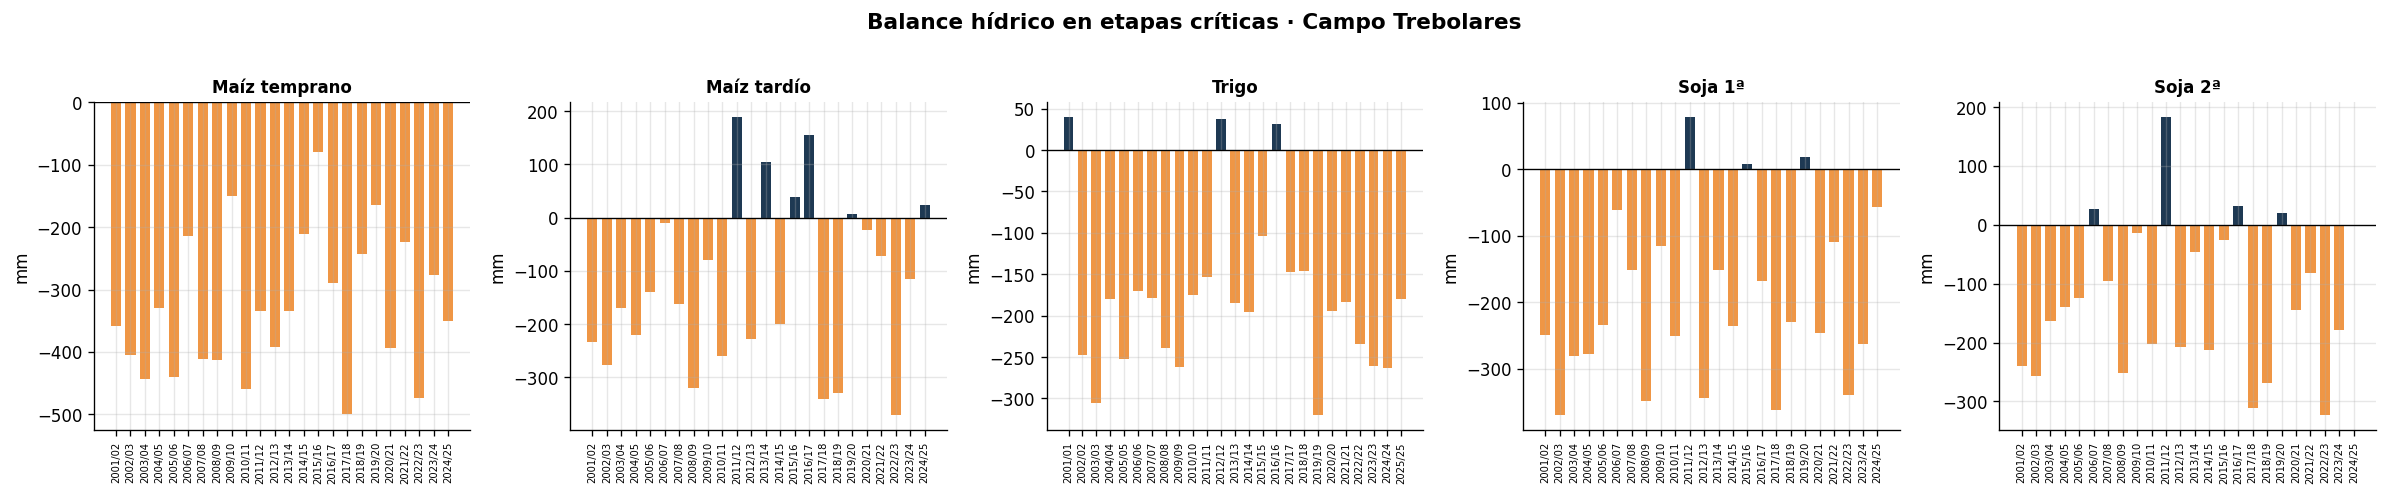

In [12]:
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=False)
if n == 1:
    axes = [axes]

for ax, (key, df) in zip(axes, campaigns.items()):
    colors_pt = [NAVY if v >= 0 else ORANGE for v in df['critical_balance_mm']]
    ax.bar(df['campaign_label'], df['critical_balance_mm'], color=colors_pt, width=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(SCENARIO_LABELS[key], fontsize=10, fontweight='bold')
    ax.set_ylabel('mm')
    ax.tick_params(axis='x', rotation=90, labelsize=6)

plt.suptitle('Balance hídrico en etapas críticas · Campo Trebolares',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 10 · Correlaciones — precipitación anual vs scores

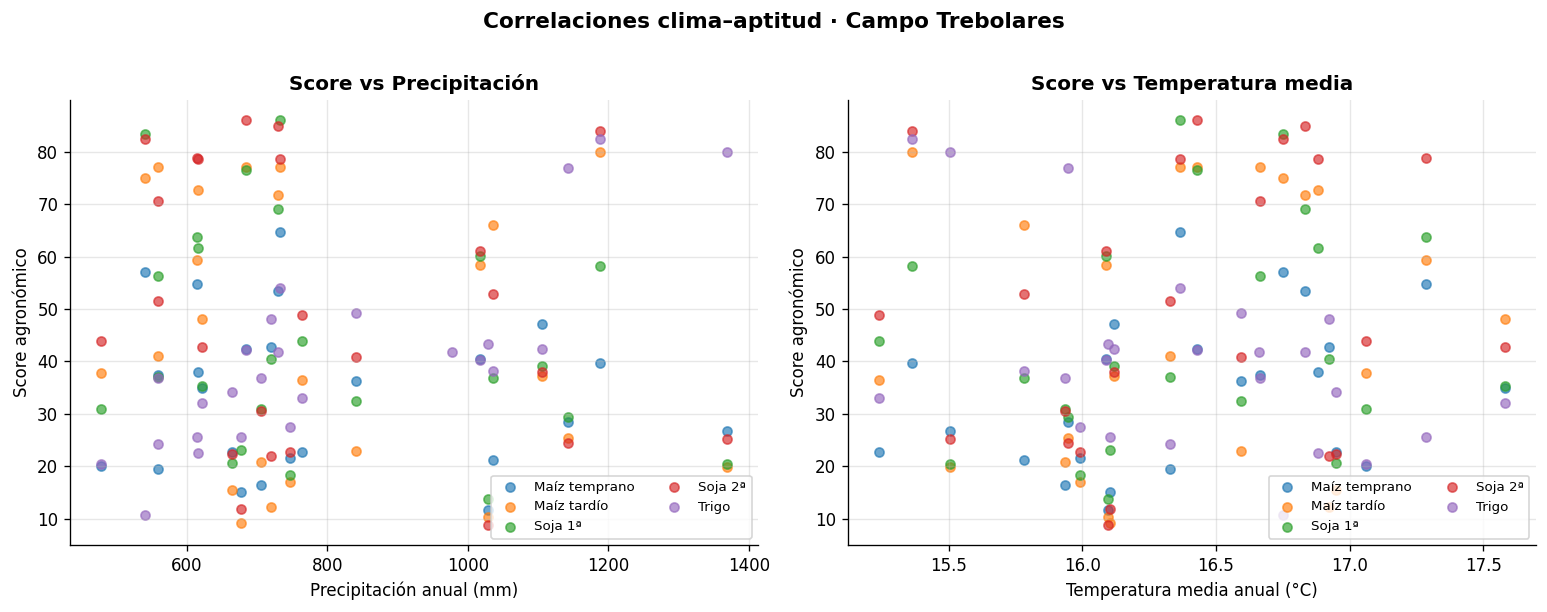

In [13]:
# Construir tabla combinada año × variables
# Extraer año de inicio de campaña para cruzar con clima anual
all_campaigns = pd.concat(
    [df.assign(scenario_key=key) for key, df in campaigns.items()],
    ignore_index=True
)

# Usar campaign_start_year si existe, si no parsear desde campaign_label
if 'campaign_start_year' in all_campaigns.columns:
    all_campaigns['year'] = all_campaigns['campaign_start_year'].astype(int)
else:
    all_campaigns['year'] = all_campaigns['campaign_label'].str[:4].astype(int)

# Cruzar con clima anual
merged = all_campaigns.merge(annual[['year', 'precipitation_mm', 'temp_mean_c']], on='year', how='left')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Score vs precipitación
ax = axes[0]
for key, grp in merged.groupby('scenario_key'):
    ax.scatter(grp['precipitation_mm'], grp['agro_score'],
               label=SCENARIO_LABELS.get(key, key), alpha=0.65, s=30)
ax.set_xlabel('Precipitación anual (mm)')
ax.set_ylabel('Score agronómico')
ax.set_title('Score vs Precipitación', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

# Score vs temperatura media
ax = axes[1]
for key, grp in merged.groupby('scenario_key'):
    ax.scatter(grp['temp_mean_c'], grp['agro_score'],
               label=SCENARIO_LABELS.get(key, key), alpha=0.65, s=30)
ax.set_xlabel('Temperatura media anual (°C)')
ax.set_ylabel('Score agronómico')
ax.set_title('Score vs Temperatura media', fontweight='bold')
ax.legend(fontsize=8, ncol=2)

plt.suptitle('Correlaciones clima–aptitud · Campo Trebolares',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 11 · Heatmap de correlaciones entre variables de campaña

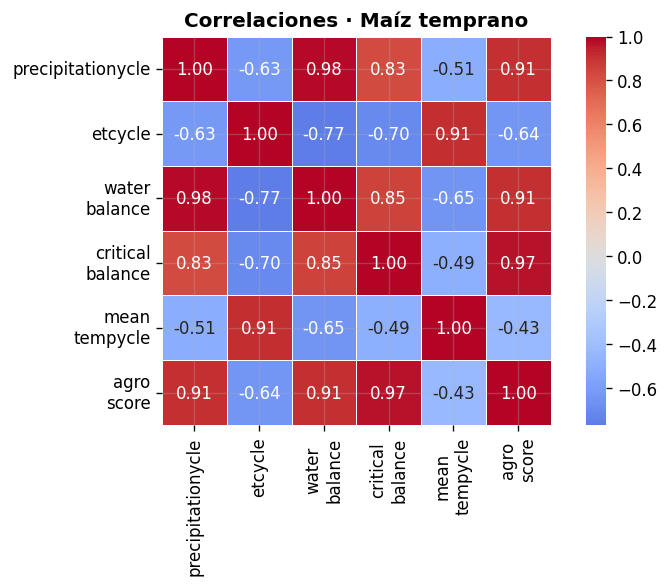

In [14]:
# Usar maíz temprano como ejemplo
key_example = 'maize_early' if 'maize_early' in campaigns else list(campaigns.keys())[0]
df_ex = campaigns[key_example].copy()

numeric_cols = [
    'precipitation_cycle_mm', 'etc_cycle_mm', 'water_balance_mm',
    'critical_balance_mm', 'mean_temp_cycle_c',
    'agro_score',
]
existing_cols = [c for c in numeric_cols if c in df_ex.columns]
corr = df_ex[existing_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True,
            xticklabels=[c.replace('_mm','').replace('_c','').replace('_','\n') for c in existing_cols],
            yticklabels=[c.replace('_mm','').replace('_c','').replace('_','\n') for c in existing_cols])
ax.set_title(f'Correlaciones · {SCENARIO_LABELS[key_example]}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12 · Suelo y terreno

In [15]:
print('=== SUELO ===')
if soil.get('available'):
    for k in ['texture_class','sand_pct','silt_pct','clay_pct','ph','organic_carbon','cec']:
        v = soil.get(k)
        if v is not None:
            print(f'  {k:<20}: {v}')
    print()
    for obs in soil.get('observations', []):
        print(f'  → {obs}')
else:
    print('  No disponible:', soil.get('error'))

print()
print('=== TERRENO ===')
if terrain.get('available'):
    for k in ['elevation_m','relief_class','drainage_risk','local_relief_range_m']:
        v = terrain.get(k)
        if v is not None:
            print(f'  {k:<25}: {v}')
    print(f'  interpretation: {terrain.get("interpretation", "")}') 
else:
    print('  No disponible:', terrain.get('error'))

=== SUELO ===
  No disponible: 503 Server Error: Service Temporarily Unavailable for url: https://rest.isric.org/soilgrids/v2.0/properties/query?lat=-35.5598&lon=-63.5924&property=sand&property=silt&property=clay&property=phh2o&property=soc&property=cec&property=cfvo&depth=0-5cm&value=mean

=== TERRENO ===
  elevation_m              : 124.0
  relief_class             : Suavemente ondulado
  drainage_risk            : Moderado
  local_relief_range_m     : 9.0
  interpretation: Entorno de poca pendiente; conviene revisar bajos, huellas de agua y cunetas.


---
## 13 · Indicadores agronómicos consolidados

In [16]:
print('=== INDICADORES CLIMÁTICOS ===')
for k, v in indicators.items():
    print(f'  {k:<30}: {v}')

print()
print('=== RESUMEN AGRONÓMICO ===')
display(summary_df)

=== INDICADORES CLIMÁTICOS ===
  annual_precip_mean            : 804.5264000000002
  wettest_year                  : {'year': 2012, 'value': 1368.71}
  driest_year                   : {'year': 2003, 'value': 477.86}
  annual_temp_mean              : 16.378785813309378
  frost_months                  : ['Jul']
  rainfall_seasonality          : Fuerte concentracion estacional
  rainfall_cv                   : 28.745107230749582
  water_stability               : Baja
  drought_risk                  : Alto
  frost_risk                    : Bajo

=== RESUMEN AGRONÓMICO ===


,Score medio,Favorable %,Intermedia %,Restrictiva %,Balance crítico (mm),Banda,Mejor campaña,Peor campaña
Escenario,,,,,,,,
Maíz temprano,34.0,0.0,20.8,79.2,-328.9,Restrictivo,2015/16,2017/18
Maíz tardío,44.5,29.2,16.7,54.2,-126.5,Restrictivo,2016/17,2022/23
Trigo,40.4,12.0,12.0,76.0,-178.9,Restrictivo,2016/16,2019/19
Soja 1ª,44.5,16.7,20.8,62.5,-197.7,Restrictivo,2015/16,2017/18
Soja 2ª,49.6,33.3,16.7,50.0,-126.2,Intermedio,2011/12,2017/18
